In [1]:
import rocketpy
from datetime import datetime, timedelta

https://docs.rocketpy.org/en/latest/user/rocket/rocket.html

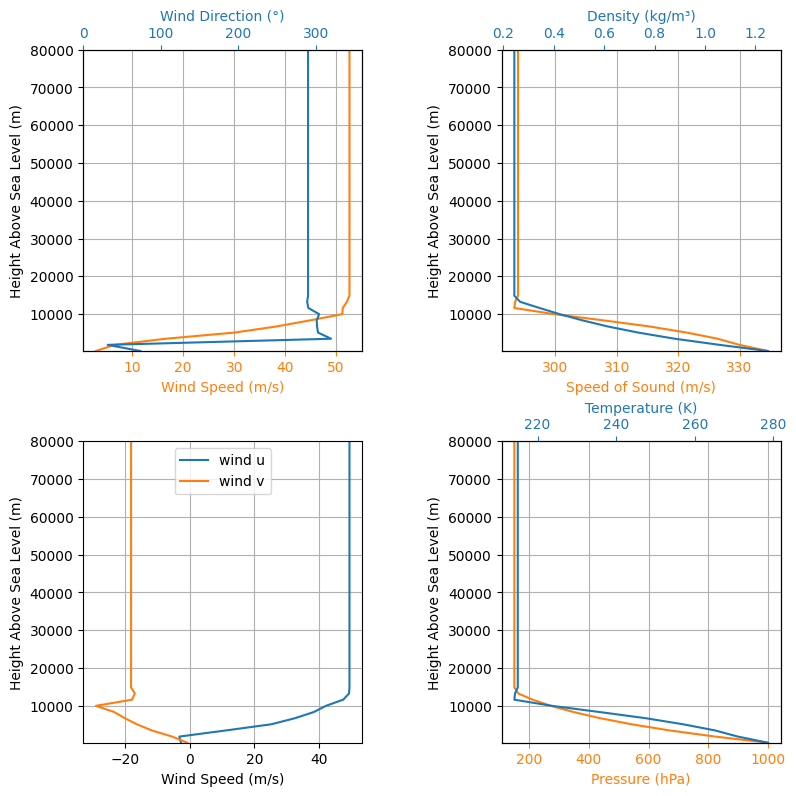

In [2]:
tomorrow = datetime.now() + timedelta(days=1)

env = rocketpy.Environment(
    latitude= 40.386772,
    longitude= -87.511283,
    elevation= 216.10,
    date = tomorrow
)
env.set_atmospheric_model(type="Windy", file="GFS")##(type="standard_atmosphere")##, file="GFS")

env.plots.atmospheric_model()

In [ ]:
#calculated from ORK component mass distribution and simulation data
Control_Freak = rocketpy.Rocket(
    radius = 0.131/2,    #m
    mass   = 16.328,     #kg dry mass
    inertia=(0.065, 11.322, 11.322), #Roll, Pitch, Yaw in kg*m^2
    power_off_drag=[
        (0.044, 0.656), (0.081, 0.507), (0.150, 0.508), (0.210, 0.511),
        (0.303, 0.515), (0.389, 0.521), (0.486, 0.530), (0.599, 0.545),
        (0.738, 0.574), (0.842, 0.612)
    ],
    power_on_drag=[
        (0.044, 0.600), (0.081, 0.450), (0.150, 0.452), (0.210, 0.455),
        (0.303, 0.458), (0.389, 0.465), (0.486, 0.472), (0.599, 0.485),
        (0.738, 0.510), (0.842, 0.545)
    ],
    center_of_mass_without_motor=1.611, #m from nose tip
    coordinate_system_orientation="nose_to_tail",
 )

#AeroTech M2400T / RMS-98/7680
motor = rocketpy.SolidMotor(
    thrust_source = 'AeroTech_M2400T.eng',
    dry_mass=2.758,      #kg
    dry_inertia=(0.0033, 0.0835, 0.0835), #kg*m^2 (RMS-98/7680 hardware)
    nozzle_radius=0.024, #m
    grain_number=3,
    grain_density=1691.3, #kg/m^3
    grain_outer_radius=0.04153, #m
    grain_initial_inner_radius=0.01429, #m
    grain_initial_height=0.1524, #m
    grain_separation=0.005,
    grains_center_of_mass_position=0.2985, #m from front of motor
    center_of_dry_mass_position=0.2985,    #m from front of motor
    nozzle_position=0,
    burn_time=3.2,
    throat_radius=0.0127, #m (0.500 in)
    coordinate_system_orientation="combustion_chamber_to_nozzle",
    )

Control_Freak.add_motor(motor, position=2.5908) #m from nose tip

nose_cone = Control_Freak.add_nose(
    length=0.6096,
    kind="von karman",
    position=0
)

#main fins
fin_set = Control_Freak.add_trapezoidal_fins(
    n=4,
    root_chord=0.305,
    tip_chord=0.152,
    span=0.133,
    position=2.1768,
    cant_angle=0.5,
    airfoil=None,
)

#canards
canards = Control_Freak.add_trapezoidal_fins(
    n=2,
    root_chord=0.0508,
    tip_chord=0.0127,
    span=0.0635,
    position=1.1938
)

tail = Control_Freak.add_tail(
    top_radius = 0.131/2,
    bottom_radius = 0.102/2,
    length = 0.076,
    position = 2.5146
)

main = Control_Freak.add_parachute(
    name="Main",
    cd_s=7.868,
    trigger=304.8,
    sampling_rate=105,
    radius=1.0668,
    height=1.8161,
    porosity=0.01,
)

drogue = Control_Freak.add_parachute(
    name="Drogue",
    cd_s=0.684,
    trigger="apogee",
    sampling_rate=105,
    radius=0.381,
    height=2.0193,
    porosity=0.01,
)




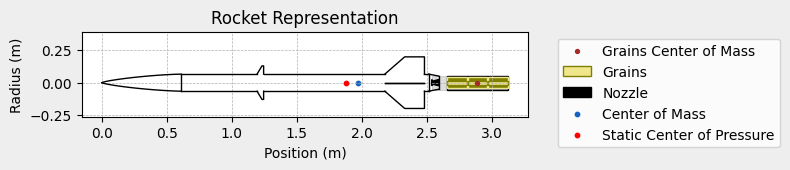

In [4]:
Control_Freak.draw()

In [ ]:
flight = rocketpy.Flight (
     rocket      = Control_Freak,
     environment = env,
     rail_length = 5.18,
     inclination = 90,    #deg — vertical launch
     heading     = 0,
)